AI-ML Assignment 7
Customer Segmentation using K-Means Clustering and PCA

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [18]:
# ---------------------------------------------------------
# Task 1: Data Understanding
# ---------------------------------------------------------
df = pd.read_csv("Mall_Customers.csv")

In [19]:
print("First 5 records:")
print(df.head())

First 5 records:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [20]:
numerical_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
categorical_features = ["Genre"]

In [21]:
print("\nNumerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical features: ['Genre']


In [22]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [23]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [24]:
# ---------------------------------------------------------
# Task 2: Data Preprocessing
# ---------------------------------------------------------
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [25]:
# CustomerID is a row identifier, not a useful feature for clustering
df = df.drop(columns=["CustomerID"])

In [26]:
print(df.columns.tolist())

['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [27]:
# encode the categorical Genre column
gender_col = "Gender" if "Gender" in df.columns else "Genre"
df[gender_col] = df[gender_col].map({"Male": 0, "Female": 1})

In [28]:
# use Annual Income and Spending Score as the primary clustering features,
# consistent with the assignment's problem statement (income and spending
# behavior); Age and Genre are retained in the dataframe but not required
# for the core segmentation task
cluster_features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[cluster_features]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
# ---------------------------------------------------------
# Task 3: Model Development
# ---------------------------------------------------------
# Elbow Method to determine the optimal number of clusters
inertias = []
k_range = range(1, 11)
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled)
    inertias.append(kmeans_test.inertia_)

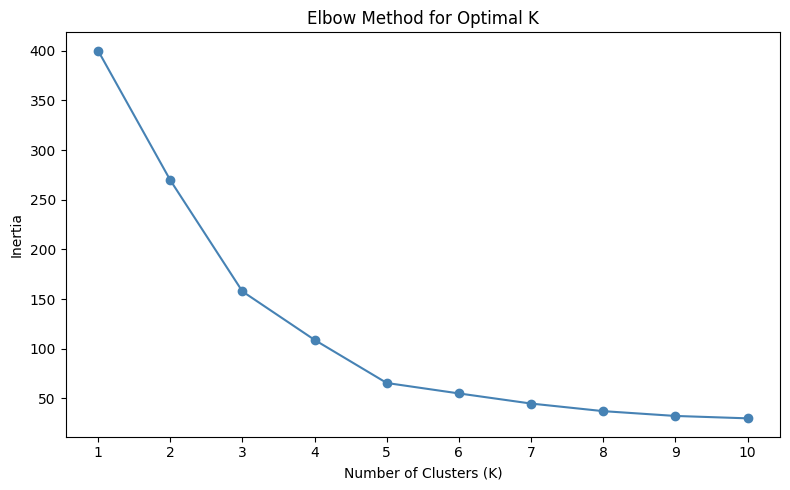

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o", color="steelblue")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()

In [32]:
# the elbow curve flattens noticeably after K=5 for this dataset
optimal_k = 5
print(f"\nSelected optimal number of clusters: {optimal_k}")


Selected optimal number of clusters: 5


In [33]:
# train the final K-Means model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df["Cluster"] = cluster_labels

In [34]:
print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())


Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


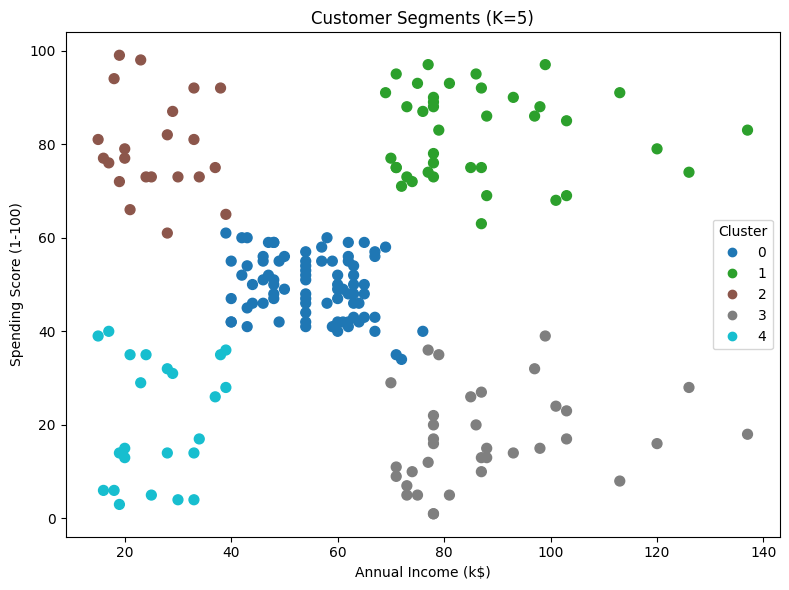

In [35]:
# scatter plot of the clusters in the original feature space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["Annual Income (k$)"], df["Spending Score (1-100)"],
    c=df["Cluster"], cmap="tab10", s=50
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"Customer Segments (K={optimal_k})")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150)
plt.show()

In [36]:
# apply PCA to reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

In [37]:
print("\nExplained variance ratio by component:", pca.explained_variance_ratio_)


Explained variance ratio by component: [0.50495142 0.49504858]


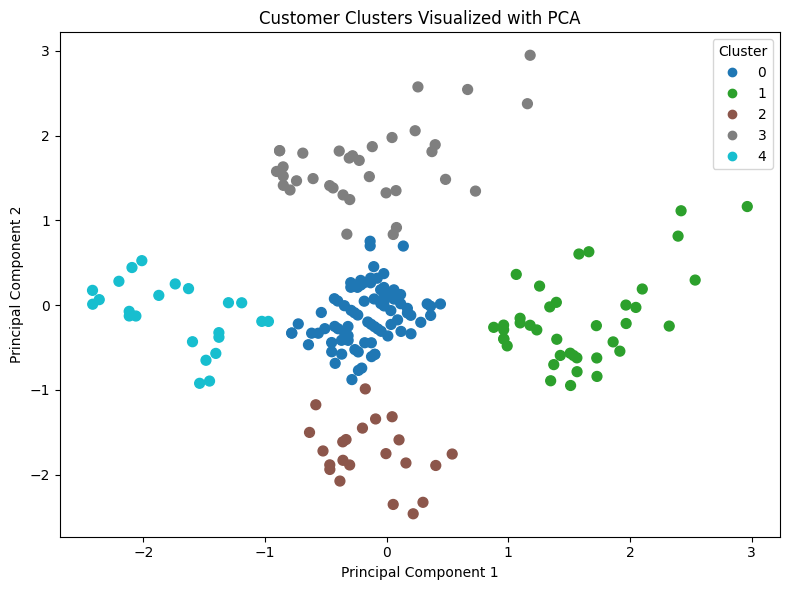

In [38]:
# ---------------------------------------------------------
# Task 4: Visualization and Evaluation
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap="tab10", s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters Visualized with PCA")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150)
plt.show()

In [39]:
print("\nCluster profile (mean values):")
print(df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1))


Cluster profile (mean values):
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9


OBSERVATIONS :
1. The elbow curve shows inertia dropping sharply up to K=5, after which
   the improvement flattens noticeably, making K=5 the optimal number of
   clusters for this dataset.
2. Since Income and Spending Score were already only two dimensions, PCA
   here mainly confirms the same cluster separation visible in the original
   scatter plot; PCA becomes more valuable when clustering is done on many
   features (e.g. including Age and Genre) and the result needs to be
   viewed in 2D. In general, PCA compresses correlated, high-dimensional
   data into a small number of components that capture most of the
   variance, making otherwise unplottable data visually interpretable.
3. The five identified segments have distinct profiles: a low-income,
   low-spending group; a low-income, high-spending group; a mid-income,
   mid-spending "average" group; a high-income, low-spending group; and a
   high-income, high-spending group - the last being the most valuable
   target for premium marketing campaigns.
4. The high-income, low-spending segment is a particularly interesting
   target for engagement campaigns, since these customers have spending
   capacity that is not currently being converted into purchases.

CONCLUSION :
This project applied K-Means Clustering to segment mall customers based on
their annual income and spending score, using the Elbow Method to select
K=5 as the optimal number of clusters, and Principal Component Analysis to
visualize the resulting groups in two dimensions. The five clusters
revealed clearly distinct customer profiles, ranging from low-income
low-spenders to high-income high-spenders, with a notable high-income
low-spending segment that represents a strong opportunity for targeted
engagement campaigns. These segments have direct business applications:
the mall's marketing team can design different promotions, loyalty
programs, or store layouts tailored to each group instead of treating all
customers uniformly, improving marketing efficiency and customer
satisfaction. One limitation of K-Means clustering is that it requires the
number of clusters (K) to be chosen in advance and assumes clusters are
roughly spherical and similarly sized, which may not hold for more complex,
irregularly shaped customer segments in real-world data. One advantage of
PCA is that it reduces high-dimensional data into a small number of
components that capture most of the variance, making it possible to
visualize and interpret patterns that would otherwise be difficult to see
across many original features at once.